In [1]:
!pip install librosa soundfile scikit-learn matplotlib seaborn


In [2]:
import os

!wget -q --show-progress https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip

Audio_Speech_Actors 100%[===================>] 198.81M  3.95MB/s    in 82s     


In [3]:
import zipfile

with zipfile.ZipFile("Audio_Speech_Actors_01-24.zip", "r") as zip_ref:
    zip_ref.extractall("RAVDESS")

print("RAVDESS dataset extracted successfully!")

RAVDESS dataset extracted successfully!


In [4]:
import os

dataset_path = "RAVDESS"

print("Dataset folders:")
print(os.listdir(dataset_path))

Dataset folders:
['Actor_11', 'Actor_02', 'Actor_20', 'Actor_22', 'Actor_01', 'Actor_09', 'Actor_15', 'Actor_04', 'Actor_06', 'Actor_16', 'Actor_18', 'Actor_13', 'Actor_24', 'Actor_08', 'Actor_07', 'Actor_03', 'Actor_23', 'Actor_17', 'Actor_21', 'Actor_14', 'Actor_12', 'Actor_19', 'Actor_05', 'Actor_10']


In [5]:
import glob

audio_files = glob.glob("RAVDESS/**/*.wav", recursive=True)

print("Total audio files:", len(audio_files))
print("First 5 files:")

for file in audio_files[:5]:
    print(file)

Total audio files: 1440
First 5 files:
RAVDESS/Actor_11/03-01-03-02-01-01-11.wav
RAVDESS/Actor_11/03-01-07-02-02-01-11.wav
RAVDESS/Actor_11/03-01-08-01-01-02-11.wav
RAVDESS/Actor_11/03-01-05-02-01-02-11.wav
RAVDESS/Actor_11/03-01-07-01-02-01-11.wav


In [6]:
import os
import glob

audio_files = glob.glob("RAVDESS/**/*.wav", recursive=True)

emotion_labels = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

emotions = []

for file in audio_files:
    filename = os.path.basename(file)
    emotion_code = filename.split("-")[2]
    emotions.append(emotion_labels[emotion_code])

print("Total files:", len(audio_files))
print("First 10 emotions:")
print(emotions[:10])

Total files: 1440
First 10 emotions:
['happy', 'disgust', 'surprised', 'angry', 'disgust', 'happy', 'sad', 'calm', 'angry', 'sad']


In [7]:
from collections import Counter

emotion_count = Counter(emotions)

print("Emotion distribution:")
for emotion, count in emotion_count.items():
    print(emotion, ":", count)

Emotion distribution:
happy : 192
disgust : 192
surprised : 192
angry : 192
sad : 192
calm : 192
fearful : 192
neutral : 96


In [8]:
import librosa
import numpy as np

X = []
y = []

for file, emotion in zip(audio_files, emotions):
    try:
        audio, sample_rate = librosa.load(file, duration=3, offset=0.5)

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=40
        )

        # Make every sample the same size
        mfcc = np.mean(mfcc.T, axis=0)

        X.append(mfcc)
        y.append(emotion)

    except Exception as e:
        print("Error:", file, e)

X = np.array(X)
y = np.array(y)

print("MFCC feature shape:", X.shape)
print("Labels shape:", y.shape)

MFCC feature shape: (1440, 40)
Labels shape: (1440,)


In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Emotion classes:")
print(label_encoder.classes_)

print("\nEncoded labels:")
print(y_encoded[:20])

Emotion classes:
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']

Encoded labels:
[4 2 7 0 2 4 6 1 0 6 3 1 3 7 2 4 6 4 2 3]


In [10]:
X_cnn = X.reshape(X.shape[0], X.shape[1], 1)

print("CNN input shape:", X_cnn.shape)

CNN input shape: (1440, 40, 1)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (1152, 40, 1)
Testing data shape: (288, 40, 1)
Training labels shape: (1152,)
Testing labels shape: (288,)


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(40, 1)),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,192 (614.03 KB)

 Trainable params: 157,192 (614.03 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1607 - loss: 3.3650 - val_accuracy: 0.1905 - val_loss: 2.0544
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2128 - loss: 1.9601 - val_accuracy: 0.2727 - val_loss: 1.9209
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2649 - loss: 1.8911 - val_accuracy: 0.2727 - val_loss: 1.9055
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2812 - loss: 1.8706 - val_accuracy: 0.2727 - val_loss: 1.9188
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3160 - loss: 1.8190 - val_accuracy: 0.3290 - val_loss: 1.8197
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3236 - loss: 1.7488 - val_accuracy: 0.3333 - val_loss: 1.7931
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3529 - loss: 1.7058 - val_accuracy: 0.4026 - val_loss: 1.7772
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3713 - loss: 1.6720 - val_accuracy: 0.4156 - v

In [15]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4896 - loss: 1.3407 
Test Loss: 1.3407297134399414
Test Accuracy: 0.4895833432674408
Test Accuracy (%): 48.95833432674408


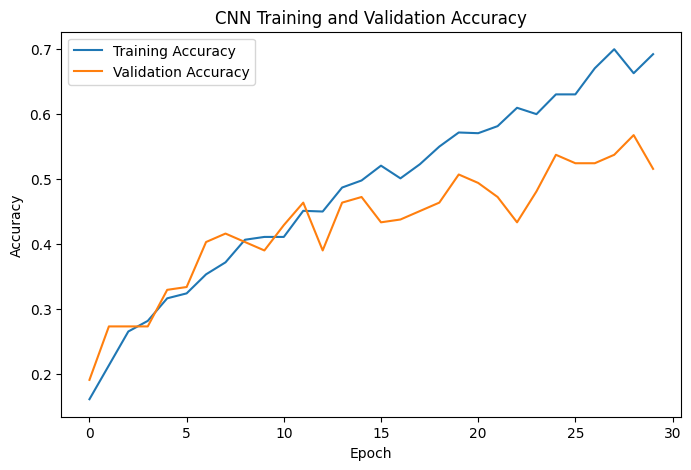

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

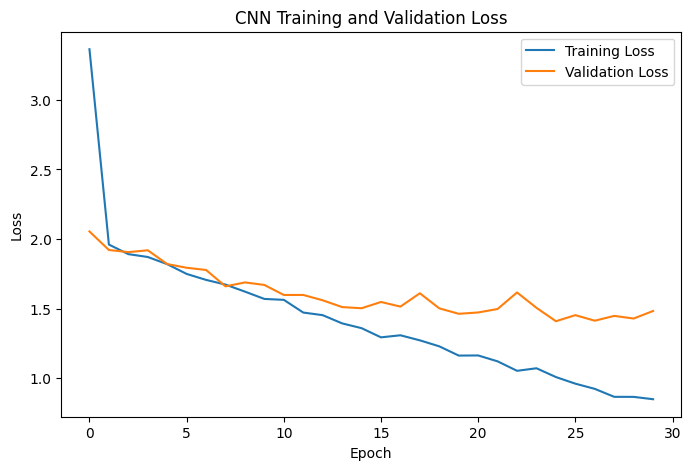

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


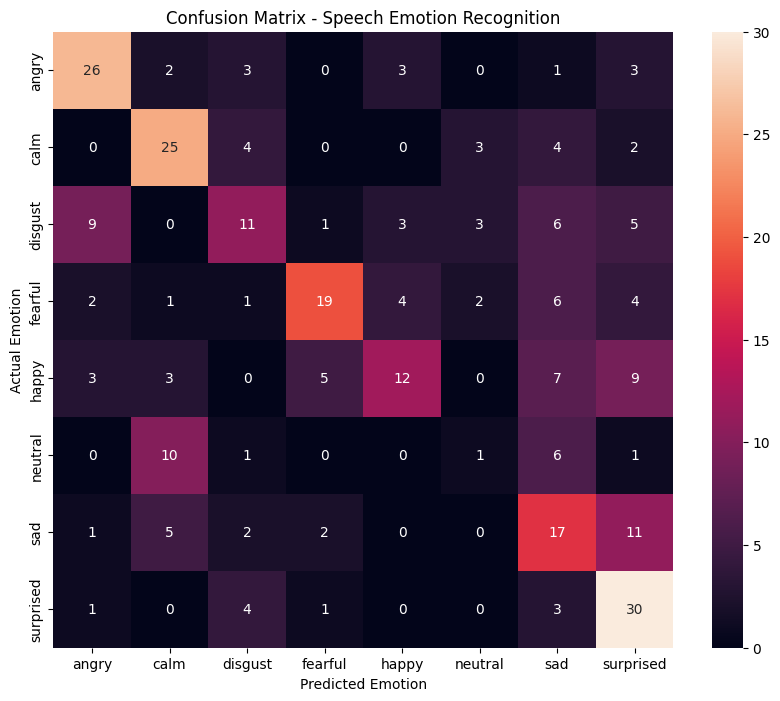

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict emotions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Confusion Matrix - Speech Emotion Recognition")
plt.show()

In [19]:
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       angry       0.62      0.68      0.65        38
        calm       0.54      0.66      0.60        38
     disgust       0.42      0.29      0.34        38
     fearful       0.68      0.49      0.57        39
       happy       0.55      0.31      0.39        39
     neutral       0.11      0.05      0.07        19
         sad       0.34      0.45      0.39        38
   surprised       0.46      0.77      0.58        39

    accuracy                           0.49       288
   macro avg       0.47      0.46      0.45       288
weighted avg       0.49      0.49      0.47       288



In [20]:
from google.colab import files

uploaded = files.upload()

In [21]:
import glob

test_file = glob.glob("RAVDESS/**/*.wav", recursive=True)[0]

print("Selected file:")
print(test_file)


Selected file:
RAVDESS/Actor_11/03-01-03-02-01-01-11.wav


In [22]:
import librosa
import numpy as np

audio, sample_rate = librosa.load(
    test_file,
    duration=3,
    offset=0.5
)

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

mfcc = np.mean(mfcc.T, axis=0)
mfcc = mfcc.reshape(1, 40, 1)

prediction = model.predict(mfcc)

predicted_class = np.argmax(prediction)

predicted_emotion = label_encoder.inverse_transform(
    [predicted_class]
)[0]

confidence = np.max(prediction) * 100

print("Predicted Emotion:", predicted_emotion)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Predicted Emotion: angry
Confidence: 54.44 %


In [23]:
model.save("speech_emotion_cnn.h5")

print("Model saved successfully!")

Model saved successfully!


In [24]:
from google.colab import files

files.download("speech_emotion_cnn.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
print("Final Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Final Test Loss:", round(test_loss, 4))

Final Test Accuracy: 48.96 %
Final Test Loss: 1.3407


In [26]:
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       angry       0.62      0.68      0.65        38
        calm       0.54      0.66      0.60        38
     disgust       0.42      0.29      0.34        38
     fearful       0.68      0.49      0.57        39
       happy       0.55      0.31      0.39        39
     neutral       0.11      0.05      0.07        19
         sad       0.34      0.45      0.39        38
   surprised       0.46      0.77      0.58        39

    accuracy                           0.49       288
   macro avg       0.47      0.46      0.45       288
weighted avg       0.49      0.49      0.47       288



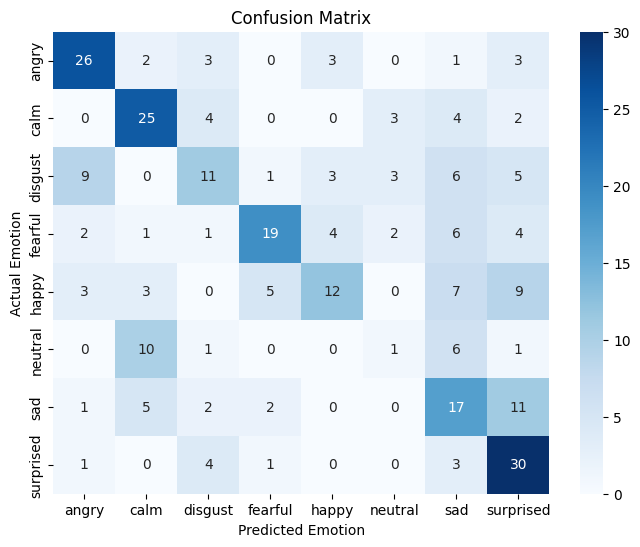

In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert predicted probabilities into class numbers
y_pred_classes = np.argmax(y_pred, axis=1)

# If y_test is one-hot encoded, convert it to class numbers
if len(y_test.shape) > 1:
    y_test_classes = np.argmax(y_test, axis=1)
else:
    y_test_classes = y_test

# Create confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Confusion Matrix")
plt.show()

In [29]:
from google.colab import files

uploaded = files.upload()

Saving speech_emotion_cnn (1).h5 to speech_emotion_cnn (1).h5


In [30]:
from google.colab import files

uploaded = files.upload()

Saving test_emotion.wav to test_emotion.wav


In [31]:
import librosa
import numpy as np

audio_file = "test_emotion.wav"

audio, sample_rate = librosa.load(audio_file, sr=22050)

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

mfcc = np.mean(mfcc.T, axis=0)

print("MFCC shape:", mfcc.shape)

MFCC shape: (40,)


In [32]:
# Reshape MFCC for the CNN model
mfcc_input = mfcc.reshape(1, 40, 1)

# Make prediction
prediction = model.predict(mfcc_input)

# Get predicted emotion
predicted_class = np.argmax(prediction, axis=1)[0]

# Convert class number to emotion name
predicted_emotion = label_encoder.inverse_transform([predicted_class])[0]

print("Predicted Emotion:", predicted_emotion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Emotion: sad


In [33]:
print("======================================")
print("   SPEECH EMOTION RECOGNITION")
print("======================================")
print("Model Accuracy : 48.96%")
print("Test Audio     : test_emotion.wav")
print("Predicted Emotion :", predicted_emotion)
print("======================================")
print("Project Completed Successfully!")

   SPEECH EMOTION RECOGNITION
Model Accuracy : 48.96%
Test Audio     : test_emotion.wav
Predicted Emotion : sad
Project Completed Successfully!
